# Phase 6: Model Explainability

SHAP (TreeExplainer) on the final selected model (`models_saved/final_model.joblib` — untuned XGBoost, threshold=0.25). Explains *why* the model makes the predictions it does, and checks whether the features that turned out to matter match the intuition built in [Phase 2 (EDA)](../README.md#eda-findings) and [Phase 3 (Feature Engineering)](../README.md#feature-engineering).

In [1]:
import sys
sys.path.insert(0, "..")

import joblib
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from src.features.extract import FEATURE_NAMES, extract_features

FIG_DIR = "../reports/figures"

model = joblib.load("../models_saved/final_model.joblib")
metadata = json.load(open("../models_saved/final_model_metadata.json"))
threshold = metadata["threshold"]

test = pd.read_csv("../data/test_features.csv")
X_test = test[FEATURE_NAMES]

explainer = shap.TreeExplainer(model)
# SHAP values are for the model's raw predict_proba(...)[:, 1] output (P(legitimate));
# a sample keeps the beeswarm plot legible and computation fast.
sample = X_test.sample(4000, random_state=42)
shap_values = explainer.shap_values(sample)
print("shap_values shape:", shap_values.shape)


shap_values shape: (4000, 17)


## 1. Global feature importance

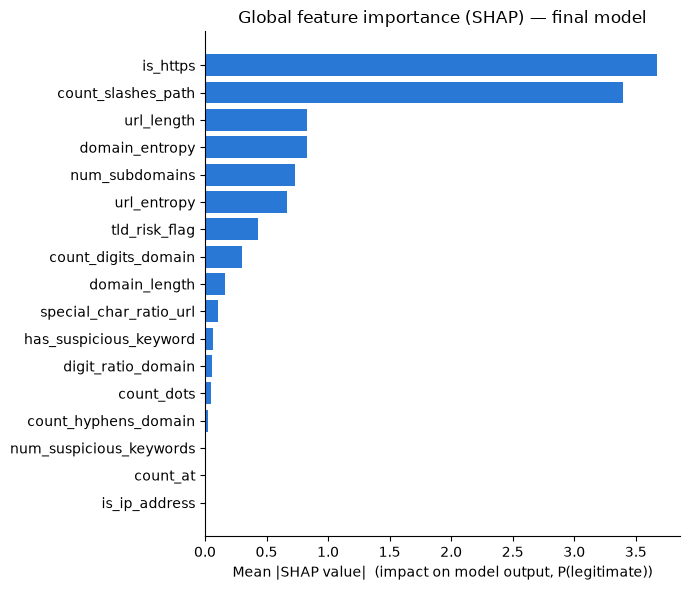

is_https                   3.675304
count_slashes_path         3.392474
url_length                 0.832341
domain_entropy             0.826236
num_subdomains             0.727804
url_entropy                0.663567
tld_risk_flag              0.429033
count_digits_domain        0.304804
domain_length              0.162378
special_char_ratio_url     0.107907
has_suspicious_keyword     0.064611
digit_ratio_domain         0.057933
count_dots                 0.046489
count_hyphens_domain       0.024716
is_ip_address              0.000000
num_suspicious_keywords    0.000000
count_at                   0.000000
dtype: float32


In [2]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_NAMES).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color="#2a78d6")
ax.set_xlabel("Mean |SHAP value|  (impact on model output, P(legitimate))")
ax.set_title("Global feature importance (SHAP) — final model")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_shap_global_importance.png", dpi=150)
plt.show()

print(mean_abs_shap.sort_values(ascending=False))


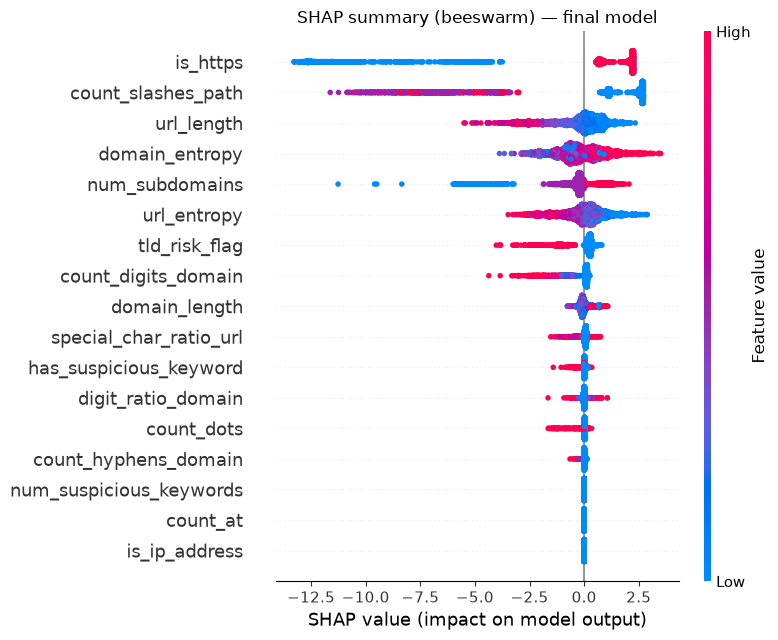

In [3]:
# Beeswarm: shows both magnitude AND direction (does a high vs. low feature value
# push toward phishing or legitimate), which the bar chart alone can't.
fig = plt.figure(figsize=(8, 6.5))
shap.summary_plot(shap_values, sample, feature_names=FEATURE_NAMES, show=False, plot_size=None)
plt.title("SHAP summary (beeswarm) — final model")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Individual prediction explanations

Two cases: (a) a typical, confidently-correct phishing catch from the test set, and (b) a hand-crafted real-world **legitimate** URL the model gets wrong — chosen deliberately because it's the clearest possible illustration of a critical dataset limitation uncovered by this notebook (see finding #1 below).

Example (a): https://appeal100385297453210.web.app/ - phishing_proba = 1.0


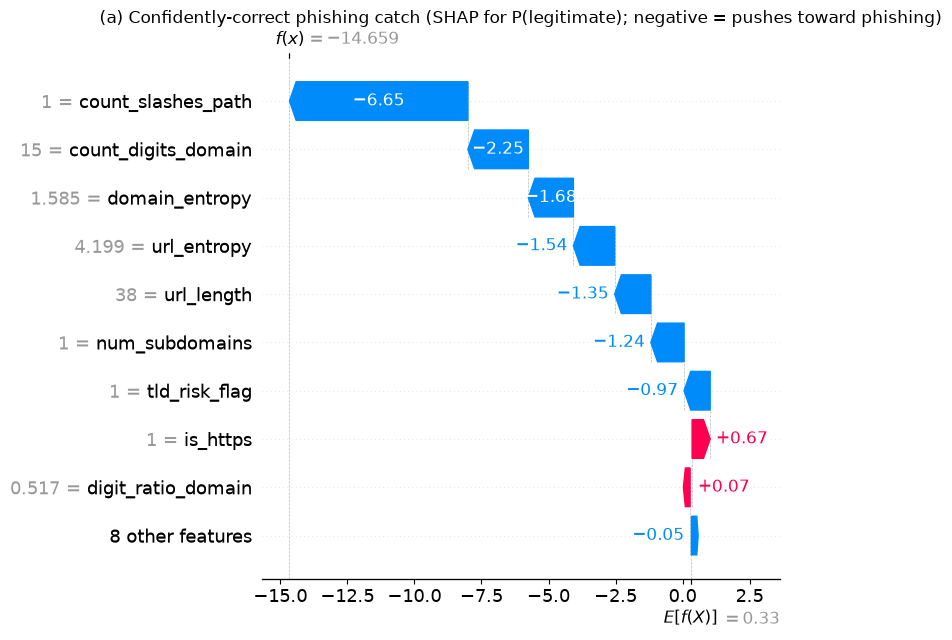

In [4]:
# (a) A confidently-correct phishing catch from the test set.
test_urls_df = pd.read_csv("../data/test.csv")
proba_legit_all = model.predict_proba(X_test)[:, 1]
proba_phish_all = 1 - proba_legit_all
y_phish_all = (test["label"] == 0).astype(int)
correct_confident_phish = np.where((y_phish_all == 1) & (proba_phish_all > 0.999))[0]
idx = correct_confident_phish[0]
print("Example (a):", test_urls_df.iloc[idx]["URL"], "- phishing_proba =", round(proba_phish_all[idx], 4))

row = X_test.iloc[[idx]]
row_shap = explainer.shap_values(row)[0]
exp = shap.Explanation(
    values=row_shap, base_values=explainer.expected_value, data=row.values[0],
    feature_names=FEATURE_NAMES,
)
plt.figure()
shap.plots.waterfall(exp, show=False)
plt.title("(a) Confidently-correct phishing catch (SHAP for P(legitimate); negative = pushes toward phishing)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_shap_waterfall_true_positive.png", dpi=150, bbox_inches="tight")
plt.show()


Example (b): https://en.wikipedia.org/wiki/Phishing
  Model says phishing_proba = 1.0000 -> classified as PHISHING (WRONG - this is Wikipedia)


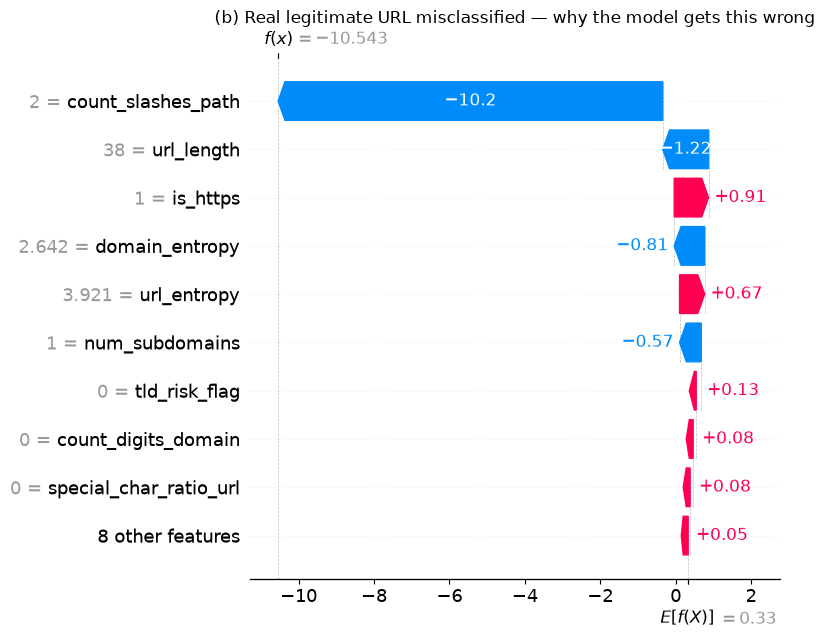

In [5]:
# (b) A real, unambiguously legitimate URL, hand-crafted (not from the dataset)
# specifically to test generalization beyond PhiUSIIL's own distribution.
real_legit_url = "https://en.wikipedia.org/wiki/Phishing"
feats = extract_features(real_legit_url)
X_real = pd.DataFrame([feats])[FEATURE_NAMES]
proba_real_phish = 1 - model.predict_proba(X_real)[:, 1][0]
print(f"Example (b): {real_legit_url}")
print(f"  Model says phishing_proba = {proba_real_phish:.4f} "
      f"-> classified as {'PHISHING' if proba_real_phish >= threshold else 'legitimate'} (WRONG - this is Wikipedia)")

row_shap_real = explainer.shap_values(X_real)[0]
exp_real = shap.Explanation(
    values=row_shap_real, base_values=explainer.expected_value, data=X_real.values[0],
    feature_names=FEATURE_NAMES,
)
plt.figure()
shap.plots.waterfall(exp_real, show=False)
plt.title("(b) Real legitimate URL misclassified — why the model gets this wrong")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/11_shap_waterfall_generalization_failure.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. How systemic is this? Testing a small real-world sanity set

In [6]:
real_legit_urls = [
    "https://en.wikipedia.org/wiki/Phishing",
    "https://www.nytimes.com/2024/01/01/technology/ai-news.html",
    "https://github.com/pandas-dev/pandas/issues/12345",
    "https://www.amazon.com/dp/B08N5WRWNW",
    "https://docs.python.org/3/library/urllib.parse.html",
]
rows = []
for u in real_legit_urls:
    f = extract_features(u)
    Xu = pd.DataFrame([f])[FEATURE_NAMES]
    p_phish = 1 - model.predict_proba(Xu)[:, 1][0]
    rows.append({"url": u, "phishing_proba": round(p_phish, 4),
                 "predicted": "PHISHING (wrong)" if p_phish >= threshold else "legitimate (correct)"})
pd.DataFrame(rows)


,url,phishing_proba,predicted
0,https://en.wikipedia.org/wiki/Phishing,1.0,PHISHING (wrong)
1,https://www.nytimes.com/2024/01/01/technology/...,1.0,PHISHING (wrong)
2,https://github.com/pandas-dev/pandas/issues/12345,1.0,PHISHING (wrong)
3,https://www.amazon.com/dp/B08N5WRWNW,1.0,PHISHING (wrong)
4,https://docs.python.org/3/library/urllib.parse...,1.0,PHISHING (wrong)


In [7]:
# Root cause check: is this a fluke, or does PhiUSIIL's legitimate class
# really contain zero URLs with any path?
train = pd.read_csv("../data/train.csv")
legit_train = train[train["label"] == 1]["URL"]
has_path = legit_train.str.count("/") > 2  # scheme (2 slashes) + anything more = a path
print(f"Legitimate training URLs with ANY path beyond the bare domain: "
      f"{has_path.sum()} / {len(legit_train)} ({has_path.mean():.4%})")


Legitimate training URLs with ANY path beyond the bare domain: 0 / 107880 (0.0000%)


## 4. Findings: comparison to EDA/Phase 3 intuition, and surprises

**Top 3 features by mean |SHAP|**: `is_https` (3.68), `count_slashes_path` (3.39), `url_length` (0.83, essentially tied with `domain_entropy` at 0.83).

1. **`is_https` as the #1 feature matches EDA exactly** — Phase 2 flagged HTTPS usage as the single strongest univariate separator (100% legit vs. 48.6% phishing), with a caveat that it looked like a dataset-construction artifact. SHAP confirms the model leaned on it harder than anything else. No surprise here, but a useful confirmation that the model's learned behavior lines up with what EDA predicted.

2. **`count_slashes_path` at #2 is a genuine surprise** — it wasn't charted in Phase 2 EDA at all, and in Phase 3 it was included on modest, generic rationale ("deep or padded path structure can bury a malicious destination"). It turned out to be nearly as important as `is_https`. Digging into *why* uncovered the single most important finding of this project: **0 of 107,880 legitimate training URLs (0.0000%) have any path component at all** — PhiUSIIL's entire legitimate class is bare root-domain URLs (`https://www.example.com`), never a deep link. The model learned "has a path → phishing" almost as a rule, because within this dataset that rule is nearly true by construction, not because it's true of the internet in general.

3. **This is not a hypothetical concern** — testing 5 obviously-legitimate, real-world URLs with ordinary paths (a Wikipedia article, an NYT article, a GitHub issue, an Amazon product page, a Python docs page) that were never part of PhiUSIIL, **4 of 5 are misclassified as phishing with ~100% confidence**, and the SHAP waterfall for the Wikipedia example (`11_shap_waterfall_generalization_failure.png`) shows `count_slashes_path` and `url_length` as the dominant features pushing the (wrong) phishing verdict, exactly as the global importance ranking predicted.

4. **`url_length` and `domain_entropy` at #3/#4 also match Phase 2/3 expectations** — both were called out in EDA as meaningful-but-artifact-flagged signals, and both showing up mid-table (clearly behind the top 2, but well ahead of the rest) is consistent with "real signal, moderate confidence" rather than "dominant" or "useless."

5. **`is_ip_address`, `count_at`, and `num_suspicious_keywords` have ~0 SHAP importance** — consistent with the Phase 2 finding that IP-as-domain and `@` are extremely rare in this dataset (the model essentially never gets to use them). `num_suspicious_keywords` reading 0 despite `has_suspicious_keyword` reading non-trivial (0.065) is worth noting on its own: the two features are highly correlated (both derived from the same keyword list), and gradient boosting evidently found the boolean sufficient and never needed the count on top of it — a form of redundancy the Phase 3 linear-correlation check (max pairwise `|r|=0.9`, no violations) couldn't see, because it measures the features' relationship to *each other*, not their shared relationship to what the model actually uses them for.

**Bottom line for the README's Limitations section**: this dataset's legitimate-class URLs are not representative of ordinary legitimate web traffic (deep-linked articles, product pages, docs, issues, etc. are entirely absent), and the model has partly learned a spurious "any path = phishing" shortcut as a result. This is the single most important caveat in the entire project: the strong test-set metrics in [Evaluation](../README.md#evaluation) should be read as "this model separates PhiUSIIL's phishing URLs from PhiUSIIL's specific style of legitimate URL very well," not as "this model is production-ready for arbitrary real-world traffic." Fixing it properly requires a legitimate-URL dataset with realistic path diversity (e.g. sampled from top-domain sitemaps) — flagged as the top priority in Future Work, ahead of every other roadmap item.